In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [67]:
# Carregar dataSet
df = pd.read_csv('transacoes_anomalias.csv')
print(df.head())
print(df.info())

    valor  frequencia  tempo_entre_compras    categoria
0  169.87          13                  9.1    vestuario
1  144.47          18                  8.1  eletronicos
2  175.91           9                  9.7  alimentacao
3  210.92           5                 12.1  eletronicos
4  140.63           7                  6.4  alimentacao
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   valor                100 non-null    float64
 1   frequencia           100 non-null    int64  
 2   tempo_entre_compras  100 non-null    float64
 3   categoria            100 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ KB
None


In [68]:
# Selecionar as variaveis de interesse
colunas = ["valor", "frequencia", "tempo_entre_compras"]
x = df[colunas]

# Padronizar os dados
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [69]:
# Treinamento
model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
model.fit(x_scaled)

IsolationForest(contamination=0.1, random_state=42)

In [70]:
# Predição das anomalias
# -1 = anomalia | 1 = normal

df["anomaly"] = model.predict(x_scaled)

# Score da anomalia (Quanto menor, mais anomolo ele é)
df["score"] = model.decision_function(x_scaled)

# Converter para rótulo legível
df["legenda"] = df["anomaly"].map({1: "normal", -1: "anomalia"})


In [71]:
# Registros
df

,valor,frequencia,tempo_entre_compras,categoria,anomaly,score,legenda
0,169.87,13,9.1,vestuario,1,0.167943,normal
1,144.47,18,8.1,eletronicos,1,0.113519,normal
2,175.91,9,9.7,alimentacao,1,0.153153,normal
3,210.92,5,12.1,eletronicos,1,0.007480,normal
4,140.63,7,6.4,alimentacao,1,0.165352,normal
...,...,...,...,...,...,...,...
95,724.38,1,32.2,alimentacao,-1,-0.084396,anomalia
96,935.53,2,35.2,eletronicos,-1,-0.034642,anomalia
97,931.33,2,26.9,eletronicos,-1,-0.053981,anomalia
98,900.61,1,27.8,eletronicos,-1,-0.017970,anomalia


In [72]:
# Visualização em gráfico

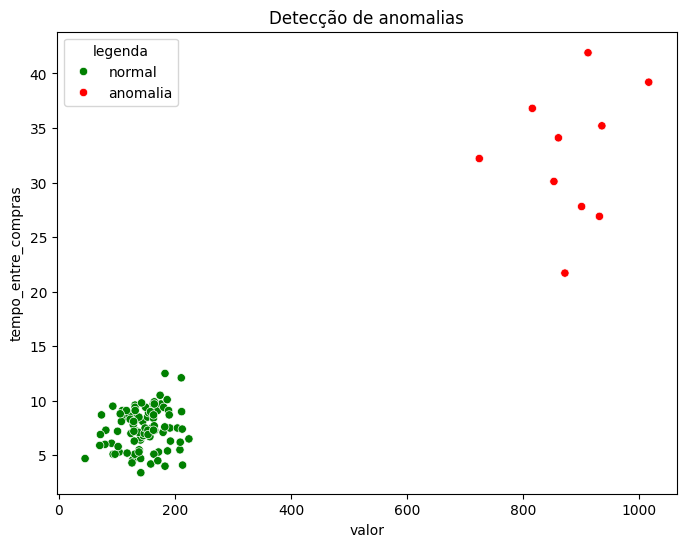

In [73]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="valor",
    y="tempo_entre_compras",
    hue="legenda",
    palette=["green", "red"]
)

plt.title("Detecção de anomalias")
plt.show()

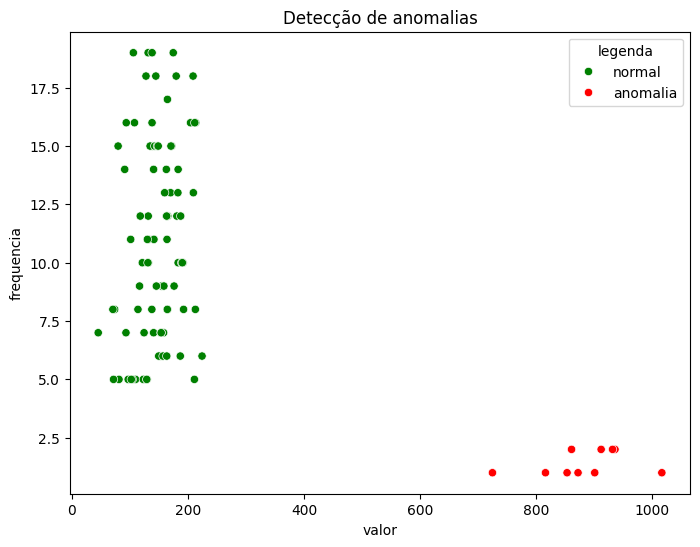

In [74]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="valor",
    y="frequencia",
    hue="legenda",
    palette=["green", "red"]
)

plt.title("Detecção de anomalias")
plt.show()